# Rerank cutoff 03 — Two-stage: global `t*` + IQR-gated gap on survivors

**Stage 1:** same as notebook 02: `t*` is chosen on **raw** rerank scores for every family
(largest `t` with macro mean residual `<= alpha` and p90 `<= beta`). Survivors are `score >= t*`.
For **bgem3** diagnostic plots only, the purple reference line is **`logit(clamp(t*))`** so it
matches the plotted `z = logit(s)` axis (gemma: purple = raw `t*` on raw `z`).

**Stage 2:** among survivors, if `m > FLOOR` apply IQR gate on gaps in `z` (logit for bgem3,
raw for gemma). **Eligible gaps** are only those for split counts in `[FLOOR, CAP]`. Among gaps
with `g > g_gate`, we report **two** policies: **strongest** (max gap; ties → latest `k`) and
**latest** (largest index `k`, i.e. shallowest cut among qualifiers). If none qualify,
keep `min(m, CAP)`.

See **Discussion** for limitations.

In [8]:
from __future__ import annotations

import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from IPython.display import display
except ImportError:
    display = print  # type: ignore[assignment]

try:
    _NB_DIR = Path(__file__).resolve().parent
except NameError:
    _NB_DIR = Path(".").resolve()
    if not (_NB_DIR / "scripts").exists():
        _NB_DIR = _NB_DIR.parent

REPO_ROOT = _NB_DIR if (_NB_DIR / "scripts").exists() else _NB_DIR.parent
assert (REPO_ROOT / "scripts").exists(), f"Cannot locate repo root (tried {REPO_ROOT})"
sys.path.insert(0, str(REPO_ROOT / "scripts" / "public" / "shared_scripts"))
sys.path.insert(0, str(REPO_ROOT / "notebooks"))

from retrieval_eval.common import build_topics_and_gold, load_questions

from _rerank_plot_sample import DEFAULT_N_GOLD_BINS, sample_queries_for_diagnostic_plots

## Configuration

In [9]:
N_CAP = 200
FLOOR = 5
CAP = 40
GAMMA_DEFAULT = 1.5
GAMMA_GRID = [1.0, 1.5, 2.0, 3.0]
CAP_GRID = [15, 20, 30, 40]
LOGIT_EPS = 1e-6

ALPHA_DEFAULT = 0.10
BETA_DEFAULT = 0.30

RNG_SEED = 42
SAMPLE_SIZE = 48
MAX_UNIQUE_T = 8000

RERANK_RUN_SOURCES: list[tuple[str, Path, bool]] = [
    (
        "bgem3",
        REPO_ROOT / "output" / "workflow_baseline_full_run_both_routes" / "rerank" / "runs",
        True,
    ),
    (
        "bge_gemma",
        REPO_ROOT / "output" / "workflow_baseline_full_run_both_routes_gemma" / "rerank" / "runs",
        False,
    ),
]

GOLD_JSON_MAP: dict[str, Path] = {
    "13B1_golden": REPO_ROOT / "bioasq_data" / "Task13BGoldenEnriched" / "13B1_golden.json",
    "13B2_golden": REPO_ROOT / "bioasq_data" / "Task13BGoldenEnriched" / "13B2_golden.json",
    "13B3_golden": REPO_ROOT / "bioasq_data" / "Task13BGoldenEnriched" / "13B3_golden.json",
    "13B4_golden": REPO_ROOT / "bioasq_data" / "Task13BGoldenEnriched" / "13B4_golden.json",
    "training14b_10pct_sample": REPO_ROOT / "example" / "training14b_10pct_sample.json",
}

## Helpers (load + `t*` sweep on raw scores, same as notebook 02)

In [10]:
def load_run_tsv(path: Path, n_cap: int = 200) -> pd.DataFrame:
    df = pd.read_csv(path, sep="\t")
    df["score"] = df["score"].astype(float)
    df["docno"] = df["docno"].astype(str)
    df = df.sort_values(["qid", "score"], ascending=[True, False])
    return df.groupby("qid").head(n_cap).reset_index(drop=True)


def load_gold_set_map(json_path: Path) -> dict[str, set[str]]:
    qs = load_questions(json_path)
    _, gold_lists = build_topics_and_gold(qs)
    return {qid: set(pmids) for qid, pmids in gold_lists.items()}


def _split_from_stem(stem: str) -> str | None:
    m = re.match(r"best_rrf_(.+?)_top\d+", stem)
    return m.group(1) if m else None


def t_star_y_on_survivor_z_plot(t_star: float | None, *, use_logit: bool) -> float | None:
    """Horizontal line y-value on survivor diagnostic (z = logit(s) for bgem3, else raw s)."""
    if t_star is None:
        return None
    if use_logit:
        s = float(np.clip(t_star, LOGIT_EPS, 1.0 - LOGIT_EPS))
        return float(np.log(s / (1.0 - s)))
    return float(t_star)


def build_t_candidates(all_scores: list[np.ndarray], max_unique: int = MAX_UNIQUE_T) -> np.ndarray:
    if not all_scores:
        return np.array([0.0])
    u = np.unique(np.concatenate([np.asarray(s, dtype=np.float64) for s in all_scores]))
    u.sort()
    if len(u) > max_unique:
        idx = np.round(np.linspace(0, len(u) - 1, max_unique)).astype(int)
        u = np.unique(u[idx])
    t0 = float(u[0] - 1e-12) if len(u) else 0.0
    return np.concatenate([[t0], u])


def sweep_thresholds_for_source(queries: list[dict]) -> pd.DataFrame:
    if not queries:
        return pd.DataFrame()
    all_scores = [q["scores"] for q in queries]
    t_candidates = build_t_candidates(all_scores)
    rows = []
    for t in t_candidates:
        losses, kepts = [], []
        for q in queries:
            sc, gm = q["scores"], q["gold_mask"]
            R = int(gm.sum())
            lost = int(np.sum((sc < t) & gm))
            losses.append(lost / R)
            kepts.append(int(np.sum(sc >= t)))
        lo = np.asarray(losses, dtype=np.float64)
        rows.append(
            dict(
                t=float(t),
                macro_mean_loss=float(lo.mean()),
                p90_loss=float(np.percentile(lo, 90)),
                mean_kept=float(np.mean(kepts)),
                median_kept=float(np.median(kepts)),
            )
        )
    return pd.DataFrame(rows)


def select_t_star(sweep: pd.DataFrame, alpha: float, beta: float) -> float | None:
    ok = (sweep["macro_mean_loss"] <= alpha) & (sweep["p90_loss"] <= beta)
    idx = np.where(ok.values)[0]
    if len(idx) == 0:
        return None
    return float(sweep["t"].values[idx[-1]])


def two_stage_keep_count(
    surv_scores: np.ndarray,
    *,
    use_logit: bool,
    floor: int,
    cap: int,
    gamma: float,
    gap_policy: str,
) -> int:
    m = len(surv_scores)
    if m <= floor:
        return m
    if use_logit:
        s = np.clip(surv_scores.astype(np.float64), LOGIT_EPS, 1.0 - LOGIT_EPS)
        z = np.log(s / (1.0 - s))
    else:
        z = surv_scores.astype(np.float64)
    gaps = z[:-1] - z[1:]
    if len(gaps) == 0:
        return min(m, cap)
    # 0-based: gap[k] = z[k]-z[k+1]; reacting at k means keeping k+1 docs.
    # Only gaps for split counts in [floor, min(m, cap)] — indices k in [floor-1, min(m-2, cap-1)].
    k_lo = floor - 1
    k_hi = min(m - 2, cap - 1)
    if k_lo > k_hi:
        return min(m, cap)
    window = gaps[k_lo : k_hi + 1]
    q1, q3 = np.percentile(window, [25, 75])
    iqr = q3 - q1
    g_gate = q3 + gamma * iqr
    eligible = [k for k in range(k_lo, k_hi + 1) if gaps[k] > g_gate]
    if not eligible:
        i_star = min(m, cap)
    elif gap_policy == "strongest":
        gmax = max(gaps[k] for k in eligible)
        ties = [k for k in eligible if gaps[k] >= gmax - 1e-15]
        k_chosen = max(ties)
        i_star = k_chosen + 1
    elif gap_policy == "latest":
        k_chosen = max(eligible)
        i_star = k_chosen + 1
    else:
        raise ValueError(f"gap_policy must be 'strongest' or 'latest', got {gap_policy!r}")
    i_star = int(np.clip(i_star, floor, cap))
    return min(m, i_star)


def pool_residual_loss(gold_in_pool: set[str], kept_docnos: list[str]) -> float:
    if not gold_in_pool:
        return float("nan")
    kset = set(kept_docnos)
    return len(gold_in_pool - kset) / len(gold_in_pool)

## 1. Load data, `t*`, two-stage keep (default gamma / floor / cap)

In [11]:
query_by_key: dict[tuple[str, str, str], dict] = {}
use_logit_by_src: dict[str, bool] = {}

for src, runs_dir, use_logit in RERANK_RUN_SOURCES:
    use_logit_by_src[src] = use_logit
    if not runs_dir.is_dir():
        print(f"[skip] {src}: missing {runs_dir}")
        continue
    for rp in sorted(runs_dir.glob("best_rrf_*_top*.tsv")):
        split = _split_from_stem(rp.stem)
        if split is None or split not in GOLD_JSON_MAP:
            continue
        gp = GOLD_JSON_MAP[split]
        if not gp.exists():
            continue
        rdf = load_run_tsv(rp, N_CAP)
        gmap = load_gold_set_map(gp)
        for qid in sorted(set(rdf["qid"].unique()) & set(gmap)):
            qdf = rdf[rdf["qid"] == qid]
            scores = qdf["score"].values.astype(np.float64)
            docnos = qdf["docno"].values.astype(str)
            gold = gmap[qid]
            pool = set(docnos)
            gold_in_pool = gold & pool
            R = len(gold_in_pool)
            gold_mask = np.array([d in gold_in_pool for d in docnos], dtype=bool)
            query_by_key[(src, split, qid)] = dict(
                scores=scores,
                docnos=docnos,
                gold_mask=gold_mask,
                gold_in_pool=gold_in_pool,
                R=R,
            )

t_star_by_src: dict[str, float | None] = {}
sweep_by_src: dict[str, pd.DataFrame] = {}

for src, _dir, _use_logit in RERANK_RUN_SOURCES:
    keys = [k for k in query_by_key if k[0] == src]
    queries = [query_by_key[k] for k in keys if query_by_key[k]["R"] > 0]
    if not queries:
        t_star_by_src[src] = None
        continue
    sw = sweep_thresholds_for_source(queries)
    sweep_by_src[src] = sw
    t_star_by_src[src] = select_t_star(sw, ALPHA_DEFAULT, BETA_DEFAULT)
    ts = t_star_by_src[src]
    print(f"{src}: t* = {ts}  (raw score axis; same sweep as notebook 02)")


def compute_two_stage_for_gamma(
    gamma: float,
    floor: int,
    cap: int,
) -> dict[tuple[str, str, str], dict]:
    out: dict[tuple[str, str, str], dict] = {}
    for key, q in query_by_key.items():
        src, split, qid = key
        t_star = t_star_by_src.get(src)
        if t_star is None:
            continue
        sc, docnos = q["scores"], list(q["docnos"])
        use_logit = use_logit_by_src[src]
        mask = sc >= t_star
        surv_s = sc[mask]
        surv_d = [docnos[i] for i in range(len(docnos)) if mask[i]]
        m = len(surv_s)
        k_s = two_stage_keep_count(
            surv_s,
            use_logit=use_logit,
            floor=floor,
            cap=cap,
            gamma=gamma,
            gap_policy="strongest",
        )
        k_l = two_stage_keep_count(
            surv_s,
            use_logit=use_logit,
            floor=floor,
            cap=cap,
            gamma=gamma,
            gap_policy="latest",
        )
        k_hard = int(np.sum(mask))
        kept_hard = [docnos[i] for i in range(len(docnos)) if mask[i]]
        out[key] = dict(
            m_surv=m,
            k_two_stage_strongest=k_s,
            k_two_stage_latest=k_l,
            kept_two_stage_strongest=surv_d[:k_s],
            kept_two_stage_latest=surv_d[:k_l],
            k_hard_only=k_hard,
            kept_hard_only=kept_hard,
            surv_scores=surv_s,
            surv_docnos=surv_d,
        )
    return out


state_default = compute_two_stage_for_gamma(GAMMA_DEFAULT, FLOOR, CAP)

bgem3: t* = 0.5120109915733337  (raw score axis; same sweep as notebook 02)
bge_gemma: t* = 6.8125  (raw score axis; same sweep as notebook 02)


## 2. Aligned trilogy tables (per split + pooled)

In [12]:
def _aggregate_method(
    keys: list[tuple[str, str, str]],
    state: dict[tuple[str, str, str], dict],
    method: str,
) -> dict:
    losses, kepts = [], []
    for key in keys:
        q = query_by_key[key]
        if q["R"] == 0:
            continue
        if method.startswith("fixed_"):
            kfix = int(method.split("_")[1])
            kept = list(q["docnos"][:kfix])
        else:
            st = state.get(key)
            if st is None:
                continue
            if method == "two_stage_strongest":
                kept = st["kept_two_stage_strongest"]
            elif method == "two_stage_latest":
                kept = st["kept_two_stage_latest"]
            else:
                kept = st["kept_hard_only"]
        losses.append(pool_residual_loss(q["gold_in_pool"], kept))
        kepts.append(len(kept))
    if not losses:
        return dict(
            n_eval=0,
            n_skipped_pool_gold=0,
            mean_res_loss=np.nan,
            median_res_loss=np.nan,
            p90_res_loss=np.nan,
            mean_kept=np.nan,
            median_kept=np.nan,
        )
    lo = np.asarray(losses, dtype=np.float64)
    kk = np.asarray(kepts, dtype=np.float64)
    return dict(
        n_eval=len(losses),
        n_skipped_pool_gold=0,
        mean_res_loss=float(lo.mean()),
        median_res_loss=float(np.median(lo)),
        p90_res_loss=float(np.percentile(lo, 90)),
        mean_kept=float(kk.mean()),
        median_kept=float(np.median(kk)),
    )


def build_aligned_tables(state: dict[tuple[str, str, str], dict]) -> pd.DataFrame:
    rows = []
    methods = ["two_stage_strongest", "two_stage_latest", "hard_only"] + [
        f"fixed_{k}" for k in (5, 10, 15, 20, 30, 40)
    ]
    for src, _d, _ in RERANK_RUN_SOURCES:
        for split in sorted({k[1] for k in query_by_key if k[0] == src}):
            keys = [k for k in query_by_key if k[0] == src and k[1] == split]
            n_sk = sum(1 for k in keys if query_by_key[k]["R"] == 0)
            for meth in methods:
                m = _aggregate_method(keys, state, meth)
                m["n_skipped_pool_gold"] = n_sk
                rows.append(
                    dict(
                        rerank_source=src,
                        split=split,
                        method=meth,
                        **m,
                    )
                )
        keys_all = [k for k in query_by_key if k[0] == src]
        n_sk = sum(1 for k in keys_all if query_by_key[k]["R"] == 0)
        for meth in methods:
            m = _aggregate_method(keys_all, state, meth)
            m["n_skipped_pool_gold"] = n_sk
            rows.append(
                dict(rerank_source=src, split="__pooled__", method=meth, **m)
            )
    return pd.DataFrame(rows)


df_align = build_aligned_tables(state_default)
_fmt = dict(
    mean_res_loss="{:.4f}",
    median_res_loss="{:.4f}",
    p90_res_loss="{:.4f}",
    mean_kept="{:.1f}",
    median_kept="{:.0f}",
)
for src in use_logit_by_src:
    print(f"\n=== Aligned methods  ({src}) ===")
    display(
        df_align[df_align["rerank_source"] == src]
        .sort_values(["split", "method"])
        .style.format(_fmt)
    )


=== Aligned methods  (bgem3) ===


,rerank_source,split,method,n_eval,n_skipped_pool_gold,mean_res_loss,median_res_loss,p90_res_loss,mean_kept,median_kept
4,bgem3,13B1_golden,fixed_10,84,1,0.5252,0.6667,0.8967,10.0,10
5,bgem3,13B1_golden,fixed_15,84,1,0.4685,0.5714,0.8750,15.0,15
6,bgem3,13B1_golden,fixed_20,84,1,0.4156,0.5000,0.7838,20.0,20
7,bgem3,13B1_golden,fixed_30,84,1,0.3542,0.4083,0.6773,30.0,30
8,bgem3,13B1_golden,fixed_40,84,1,0.3045,0.3170,0.6129,40.0,40
3,bgem3,13B1_golden,fixed_5,84,1,0.5961,0.7929,0.9661,5.0,5
2,bgem3,13B1_golden,hard_only,84,1,0.0522,0.0000,0.1245,137.0,200
1,bgem3,13B1_golden,two_stage_latest,84,1,0.4368,0.5000,0.8556,16.5,15
0,bgem3,13B1_golden,two_stage_strongest,84,1,0.5077,0.5714,0.9419,11.6,9
13,bgem3,13B2_golden,fixed_10,85,0,0.5200,0.6774,0.8863,10.0,10



=== Aligned methods  (bge_gemma) ===


,rerank_source,split,method,n_eval,n_skipped_pool_gold,mean_res_loss,median_res_loss,p90_res_loss,mean_kept,median_kept
58,bge_gemma,13B1_golden,fixed_10,85,0,0.5012,0.6667,0.8692,10.0,10
59,bge_gemma,13B1_golden,fixed_15,85,0,0.4385,0.5385,0.8326,15.0,15
60,bge_gemma,13B1_golden,fixed_20,85,0,0.3890,0.4286,0.7588,20.0,20
61,bge_gemma,13B1_golden,fixed_30,85,0,0.3208,0.3529,0.6588,30.0,30
62,bge_gemma,13B1_golden,fixed_40,85,0,0.2615,0.2000,0.6106,40.0,40
57,bge_gemma,13B1_golden,fixed_5,85,0,0.5829,0.7857,0.9431,5.0,5
56,bge_gemma,13B1_golden,hard_only,85,0,0.0521,0.0000,0.1302,123.8,130
55,bge_gemma,13B1_golden,two_stage_latest,85,0,0.3993,0.4286,0.8432,18.3,15
54,bge_gemma,13B1_golden,two_stage_strongest,85,0,0.4684,0.5556,0.8757,12.6,8
67,bge_gemma,13B2_golden,fixed_10,85,0,0.5105,0.6667,0.8750,10.0,10


## 3. Sensitivity: gamma and cap


=== Gamma sensitivity (two-stage strongest vs latest, default floor/cap) ===


,rerank_source,gap_policy,gamma,n_eval,n_skipped_pool_gold,mean_res_loss,median_res_loss,p90_res_loss,mean_kept,median_kept
12,bge_gemma,latest,1.000000,880,0,0.4418,0.5000,0.9000,19.0,17
13,bge_gemma,latest,1.500000,880,0,0.4647,0.5000,0.9236,17.0,15
14,bge_gemma,latest,2.000000,880,0,0.4758,0.5298,1.0000,16.7,13
15,bge_gemma,latest,3.000000,880,0,0.4460,0.4629,0.9475,19.9,14
8,bge_gemma,strongest,1.000000,880,0,0.5403,0.6667,1.0000,11.1,8
9,bge_gemma,strongest,1.500000,880,0,0.5297,0.6429,1.0000,12.1,8
10,bge_gemma,strongest,2.000000,880,0,0.5134,0.6091,1.0000,13.7,9
11,bge_gemma,strongest,3.000000,880,0,0.4597,0.4947,1.0000,18.9,11
4,bgem3,latest,1.000000,874,0,0.4828,0.5455,1.0000,18.7,17
5,bgem3,latest,1.500000,874,0,0.5036,0.5714,1.0000,16.5,14


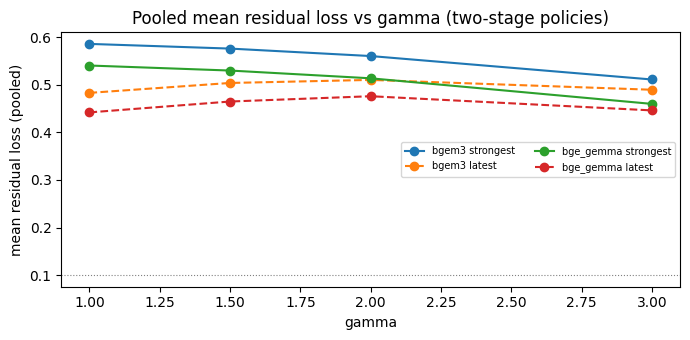


=== Cap sensitivity (strongest vs latest, default gamma) ===


,rerank_source,gap_policy,cap,n_eval,n_skipped_pool_gold,mean_res_loss,median_res_loss,p90_res_loss,mean_kept,median_kept
12,bge_gemma,latest,15,880,0,0.5357,0.6429,1.0000,11.1,13
13,bge_gemma,latest,20,880,0,0.5192,0.6091,1.0000,12.5,11
14,bge_gemma,latest,30,880,0,0.4881,0.5556,1.0000,14.8,12
15,bge_gemma,latest,40,880,0,0.4647,0.5000,0.9236,17.0,15
8,bge_gemma,strongest,15,880,0,0.5392,0.6471,1.0000,10.9,12
9,bge_gemma,strongest,20,880,0,0.5292,0.6364,1.0000,11.8,9
10,bge_gemma,strongest,30,880,0,0.5252,0.6364,1.0000,12.3,9
11,bge_gemma,strongest,40,880,0,0.5297,0.6429,1.0000,12.1,8
4,bgem3,latest,15,874,0,0.5749,0.7029,1.0000,10.7,11
5,bgem3,latest,20,874,0,0.5498,0.6667,1.0000,12.1,11


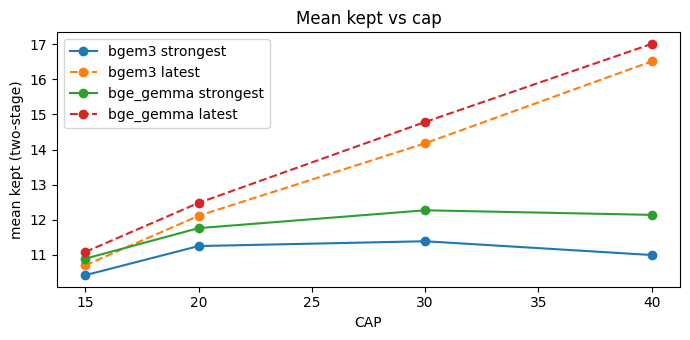

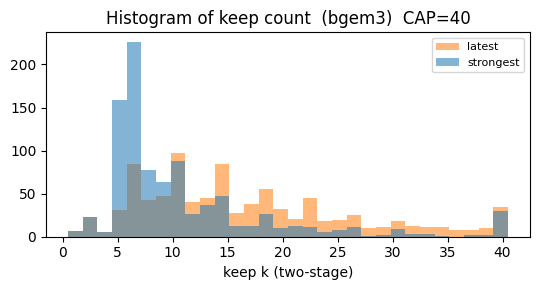

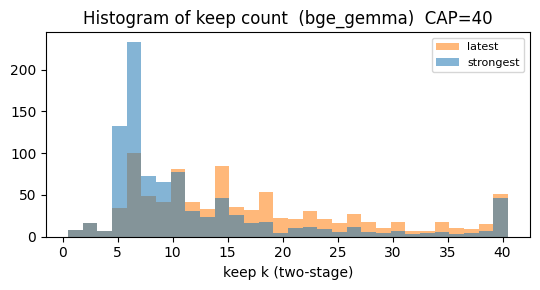

In [13]:
gamma_curve_rows = []
for src, _d, _ in RERANK_RUN_SOURCES:
    for gap_pol in ("strongest", "latest"):
        for g in GAMMA_GRID:
            st = compute_two_stage_for_gamma(g, FLOOR, CAP)
            keys = [k for k in query_by_key if k[0] == src]
            m = _aggregate_method(keys, st, f"two_stage_{gap_pol}")
            gamma_curve_rows.append(
                dict(rerank_source=src, gap_policy=gap_pol, gamma=g, **m)
            )

df_gamma = pd.DataFrame(gamma_curve_rows)
print("\n=== Gamma sensitivity (two-stage strongest vs latest, default floor/cap) ===")
display(df_gamma.sort_values(["rerank_source", "gap_policy", "gamma"]).style.format(_fmt))

plt.figure(figsize=(7, 3.5))
for src in df_gamma["rerank_source"].unique():
    for gap_pol, sty in (("strongest", "-"), ("latest", "--")):
        sub = df_gamma[
            (df_gamma["rerank_source"] == src) & (df_gamma["gap_policy"] == gap_pol)
        ].sort_values("gamma")
        plt.plot(
            sub["gamma"],
            sub["mean_res_loss"],
            marker="o",
            ls=sty,
            label=f"{src} {gap_pol}",
        )
plt.axhline(ALPHA_DEFAULT, color="gray", ls=":", lw=0.8)
plt.xlabel("gamma")
plt.ylabel("mean residual loss (pooled)")
plt.title("Pooled mean residual loss vs gamma (two-stage policies)")
plt.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

cap_rows = []
for src, _d, _ in RERANK_RUN_SOURCES:
    for gap_pol in ("strongest", "latest"):
        for c in CAP_GRID:
            st = compute_two_stage_for_gamma(GAMMA_DEFAULT, FLOOR, c)
            keys = [k for k in query_by_key if k[0] == src]
            m = _aggregate_method(keys, st, f"two_stage_{gap_pol}")
            cap_rows.append(dict(rerank_source=src, gap_policy=gap_pol, cap=c, **m))

print("\n=== Cap sensitivity (strongest vs latest, default gamma) ===")
display(pd.DataFrame(cap_rows).sort_values(["rerank_source", "gap_policy", "cap"]).style.format(_fmt))

plt.figure(figsize=(7, 3.5))
for src in {r["rerank_source"] for r in cap_rows}:
    for gap_pol, sty in (("strongest", "-"), ("latest", "--")):
        sub = pd.DataFrame(
            [
                r
                for r in cap_rows
                if r["rerank_source"] == src and r["gap_policy"] == gap_pol
            ]
        ).sort_values("cap")
        plt.plot(sub["cap"], sub["mean_kept"], marker="o", ls=sty, label=f"{src} {gap_pol}")
plt.xlabel("CAP")
plt.ylabel("mean kept (two-stage)")
plt.title("Mean kept vs cap")
plt.legend()
plt.tight_layout()
plt.show()

# histogram of k_two_stage (strongest vs latest overlaid)
for src in use_logit_by_src:
    ks_s = [state_default[k]["k_two_stage_strongest"] for k in state_default if k[0] == src]
    ks_l = [state_default[k]["k_two_stage_latest"] for k in state_default if k[0] == src]
    hdata = [x for x in (ks_s, ks_l) if x]
    hlabels = [lb for x, lb in ((ks_s, "strongest"), (ks_l, "latest")) if x]
    if not hdata:
        continue
    plt.figure(figsize=(5.5, 3))
    nb = min(30, max(8, CAP))
    plt.hist(
        hdata,
        bins=nb,
        range=(0.5, CAP + 0.5),
        label=hlabels,
        alpha=0.55,
        histtype="stepfilled",
    )
    plt.xlabel("keep k (two-stage)")
    plt.title(f"Histogram of keep count  ({src})  CAP={CAP}")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

## 4. Canonical 48 — survivor `z`, `t*` reference on `z` (logit(`t*`) for bgem3), and both gap cuts

Re-run this cell (or **Run All**) after edits; the `.ipynb` can still display **old embedded plot
outputs** until the cell executes again.

[diag plot] bgem3: raw t*=0.5120109915733337  ->  purple y=0.04805321084210622  (bgem3 uses logit for y; re-run cell if line sits at raw t* on logit axis)


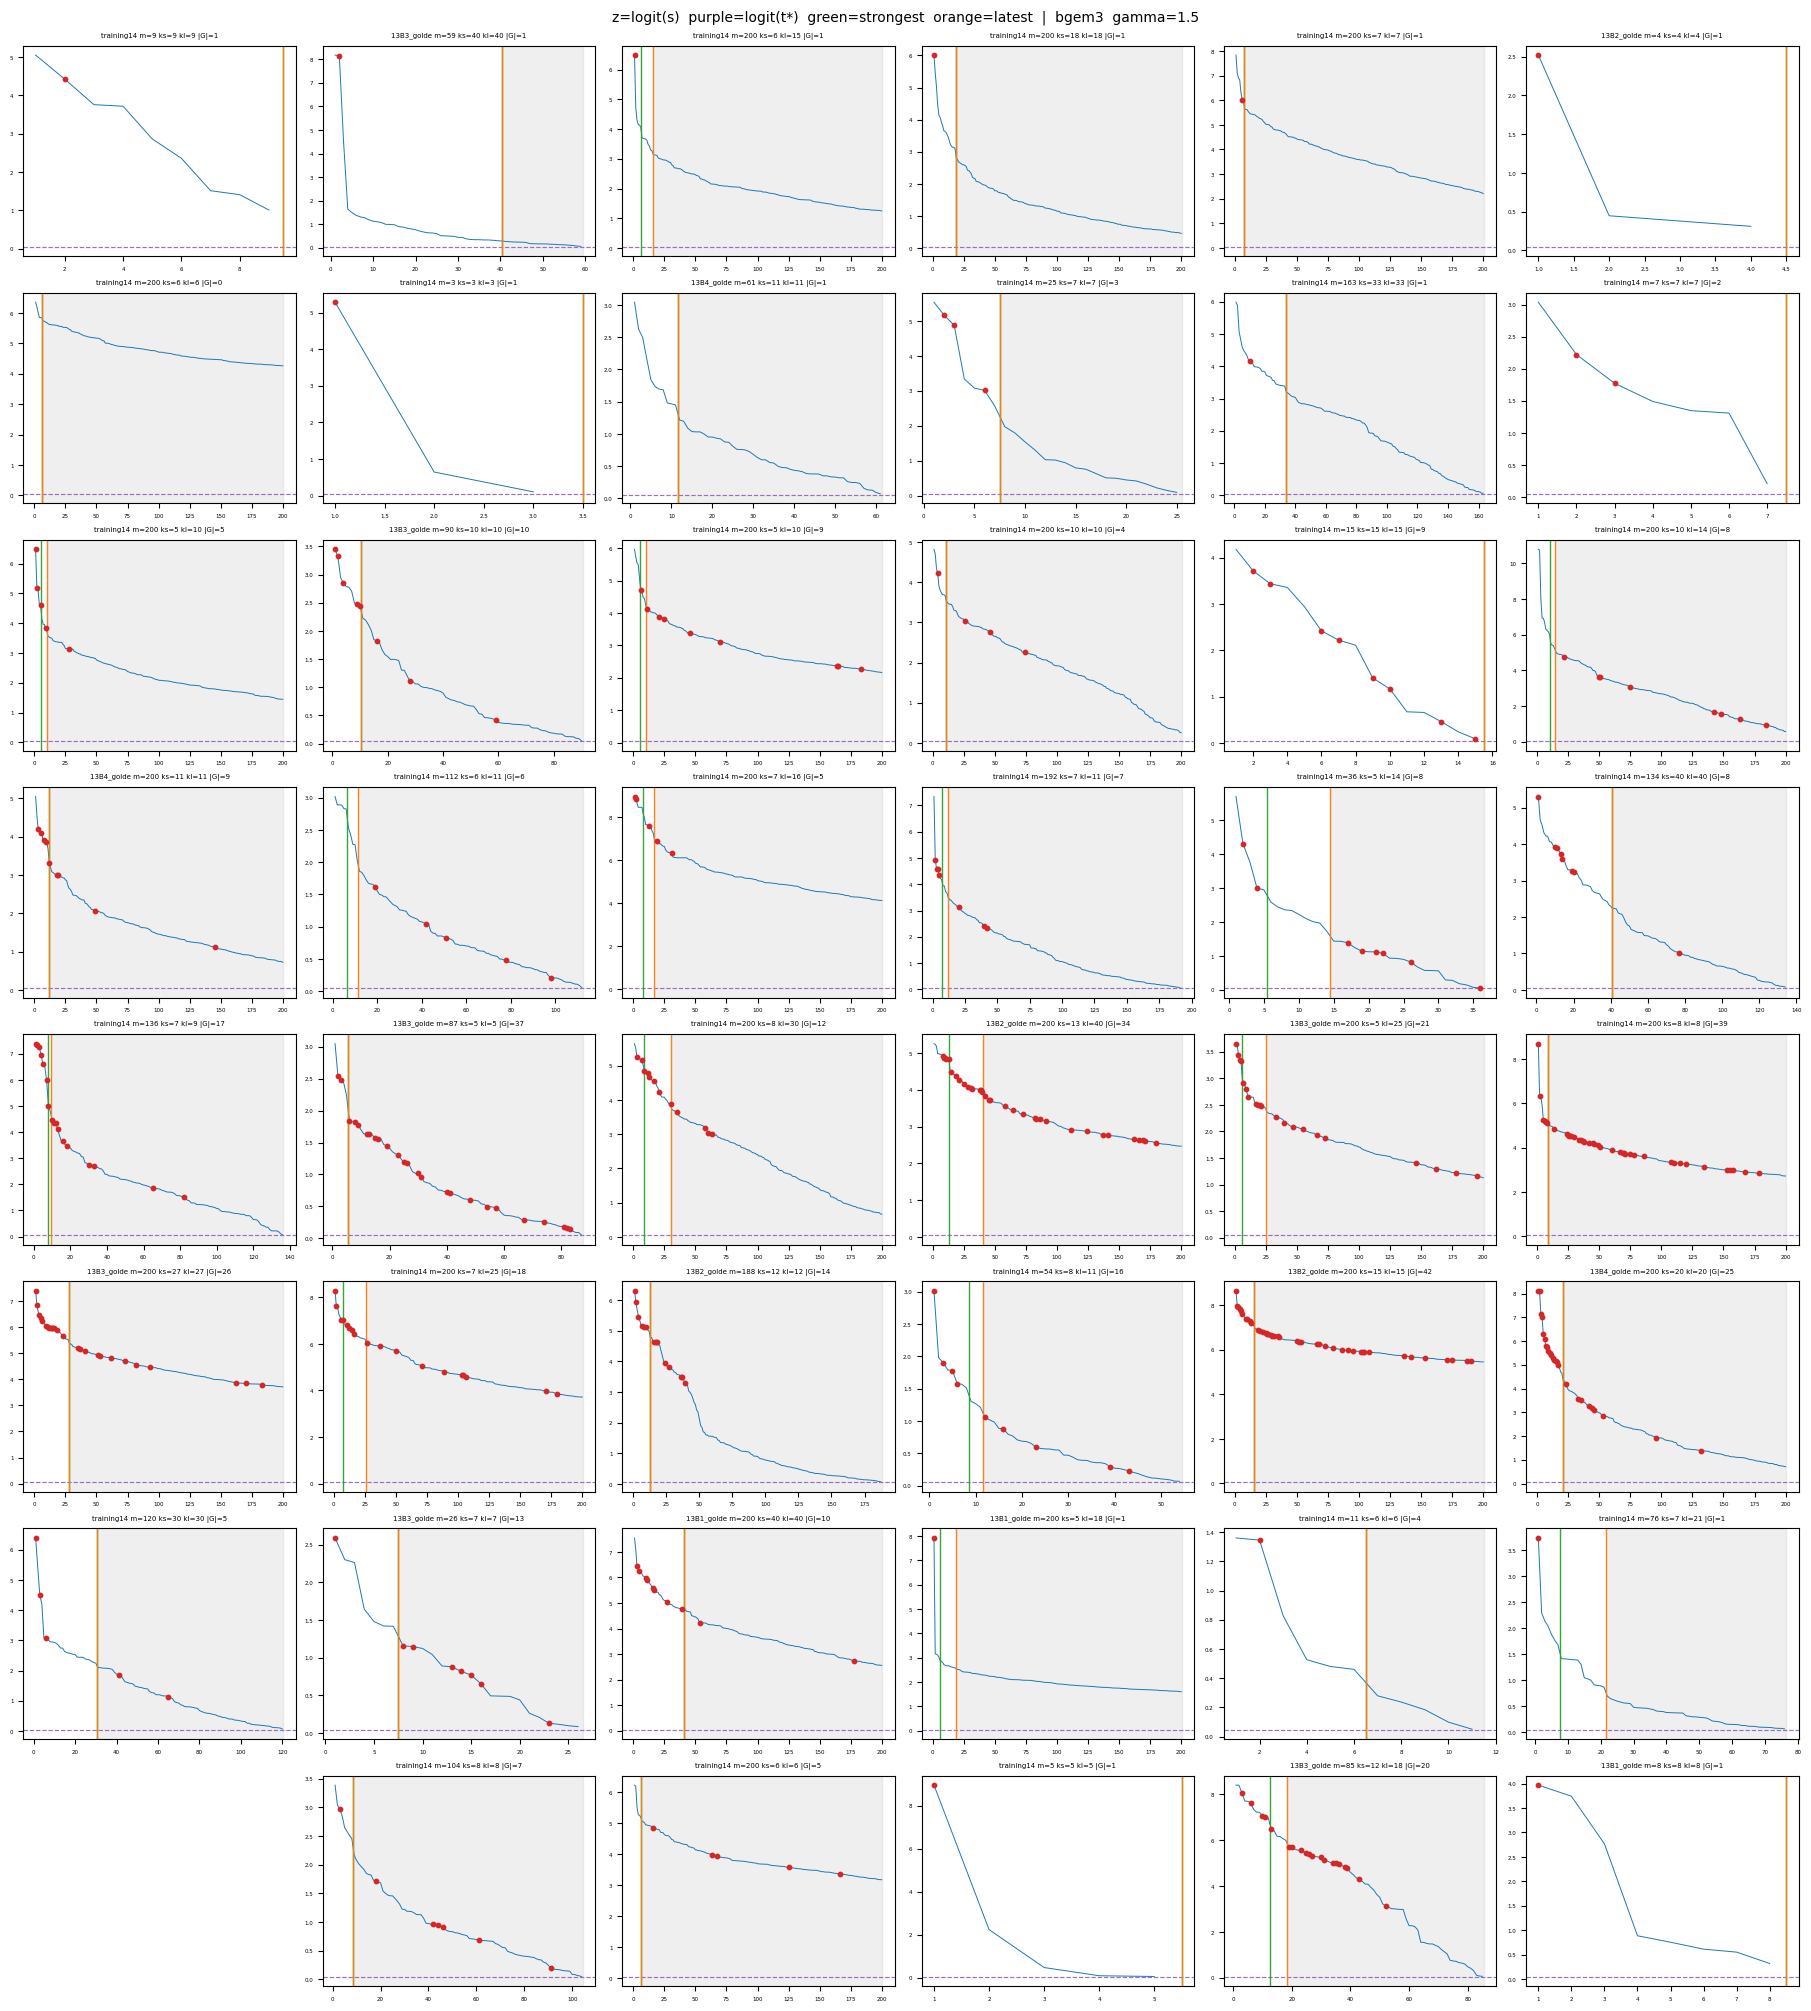

[diag plot] bge_gemma: raw t*=6.8125  ->  purple y=6.8125  (bgem3 uses logit for y; re-run cell if line sits at raw t* on logit axis)


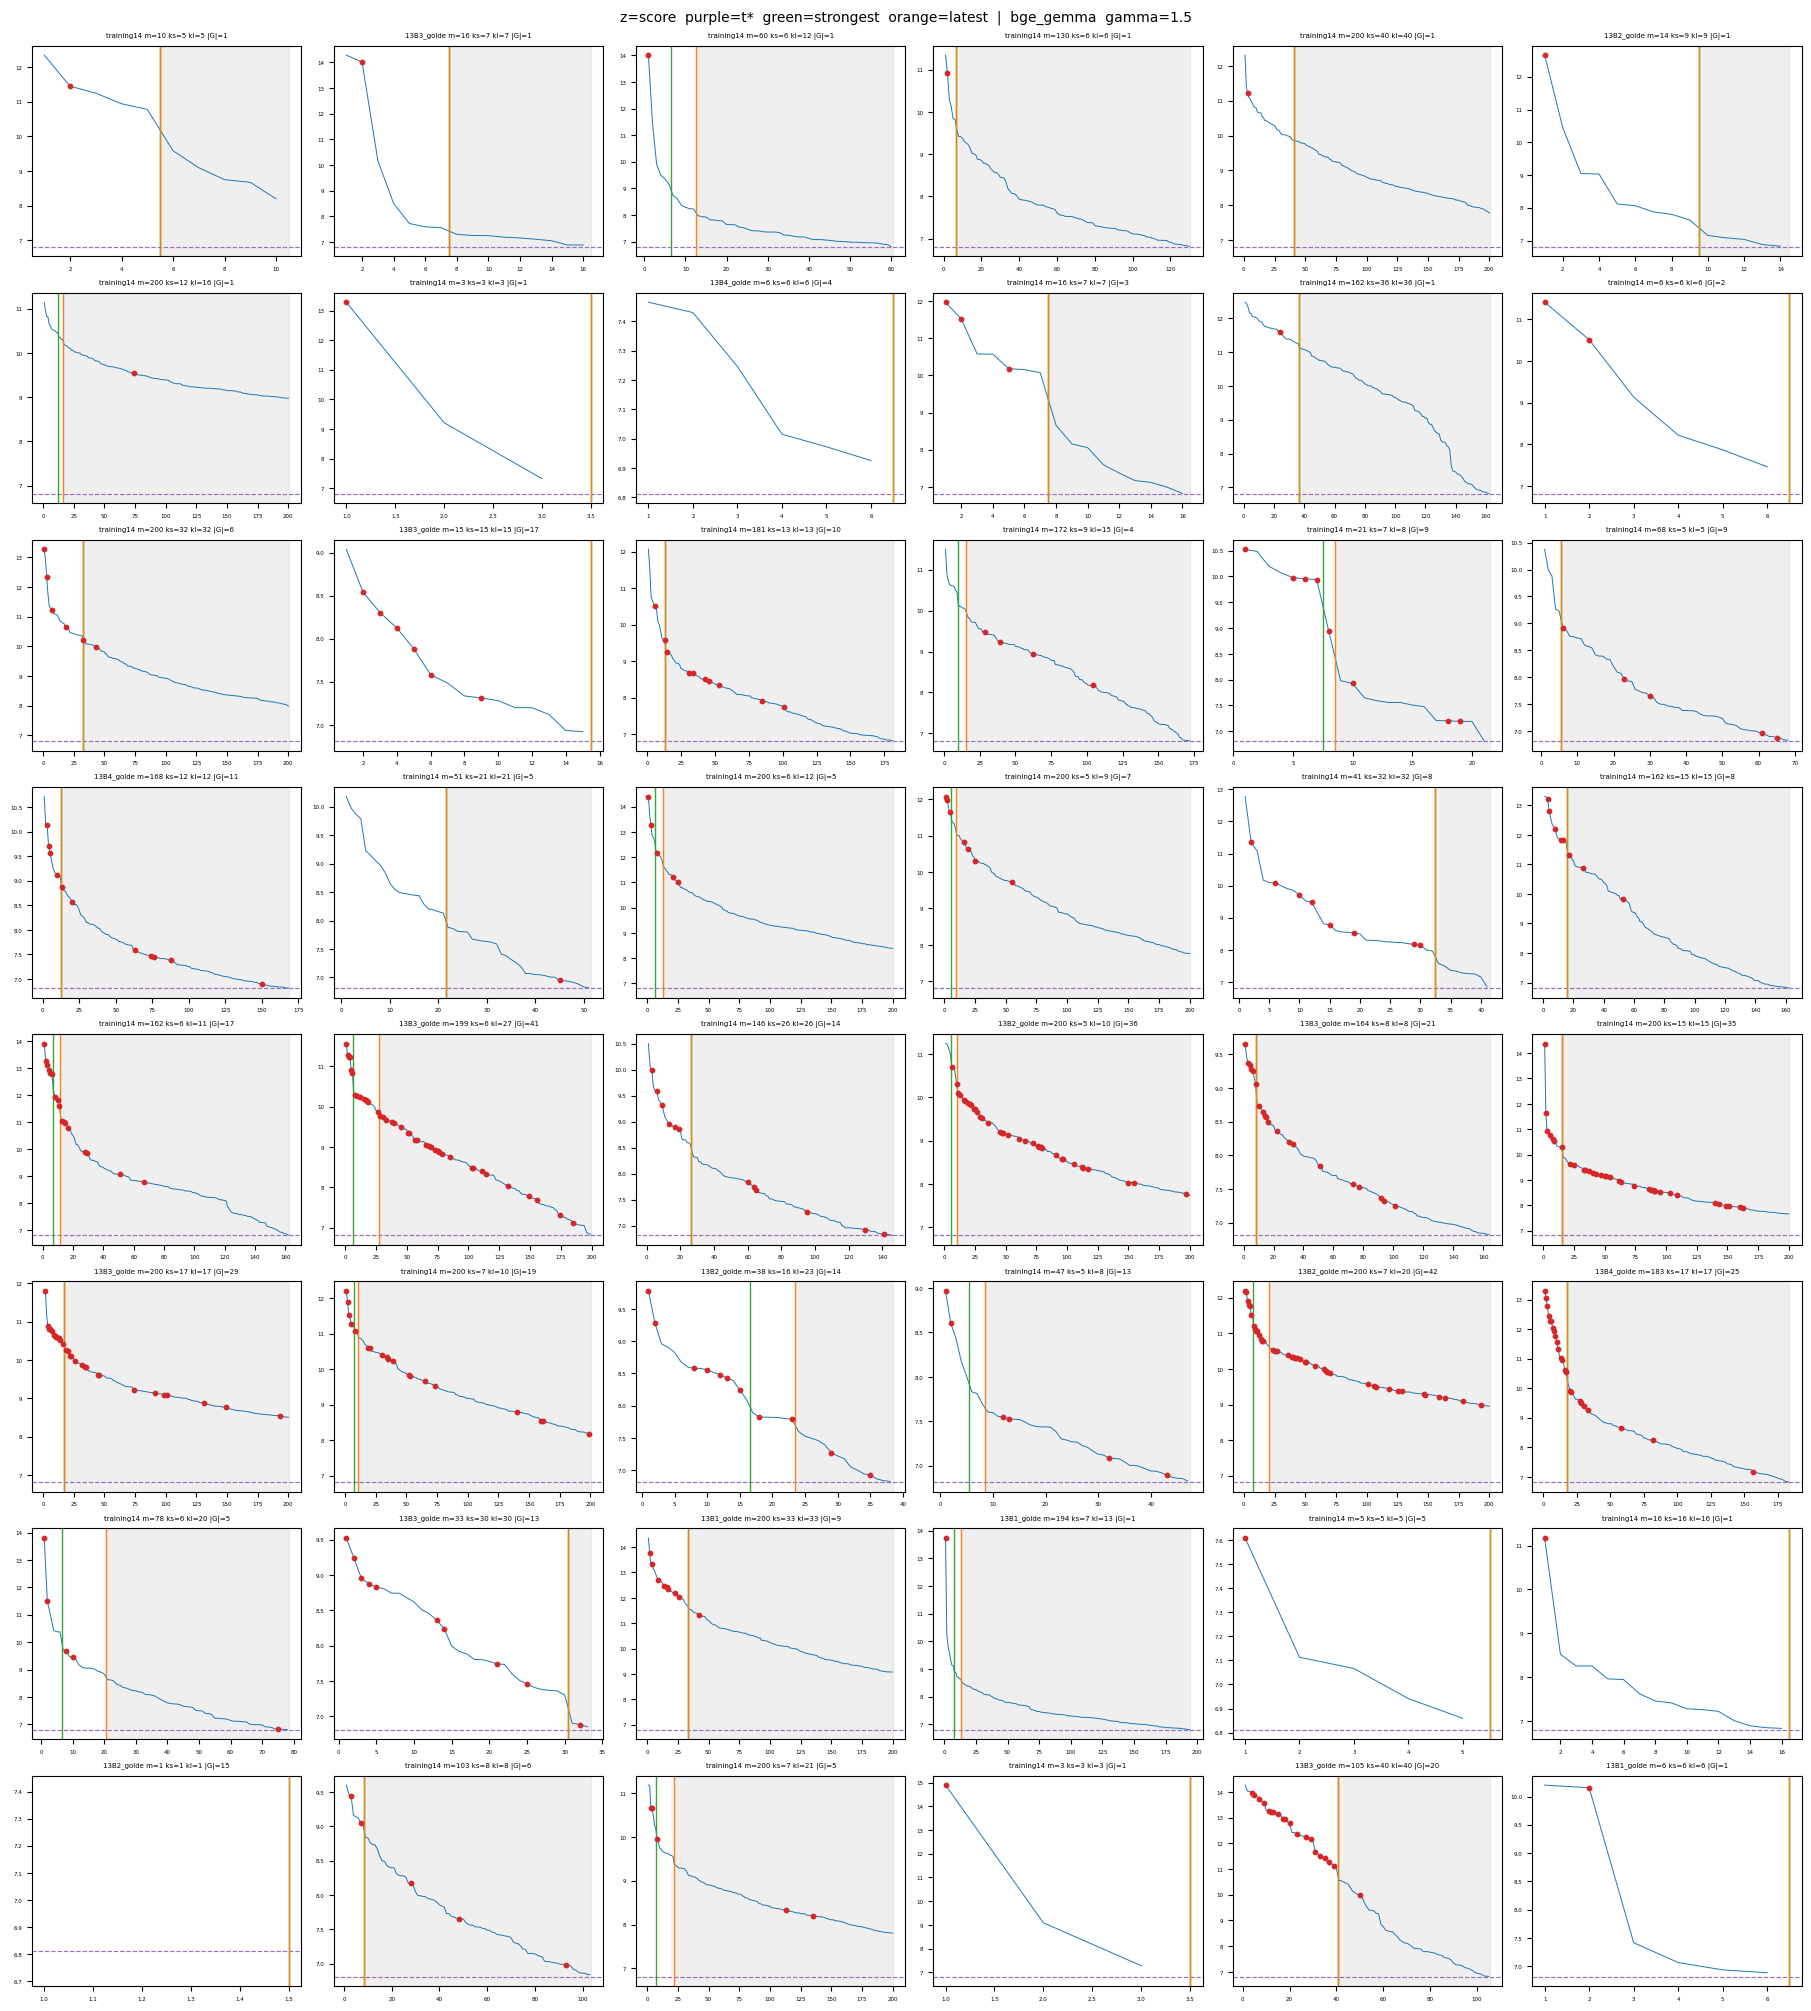

In [14]:
df_meta = pd.DataFrame(
    [
        dict(
            rerank_source=k[0],
            split=k[1],
            qid=k[2],
            n_pool_gold=query_by_key[k]["R"],
        )
        for k in query_by_key
    ]
)
canonical_pool = (
    df_meta[df_meta["n_pool_gold"] > 0][["split", "qid", "n_pool_gold"]]
    .rename(columns={"n_pool_gold": "n_gold"})
    .drop_duplicates(subset=["split", "qid"], keep="first")
)
canonical_48 = sample_queries_for_diagnostic_plots(
    canonical_pool,
    sample_size=SAMPLE_SIZE,
    rng_seed=RNG_SEED,
    n_gold_bins=DEFAULT_N_GOLD_BINS,
)

for src, _d, use_logit in RERANK_RUN_SOURCES:
    ncols = 6
    nrows = (len(canonical_48) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.0, nrows * 2.5), constrained_layout=True)
    axf = np.asarray(axes).flatten()
    ts_raw = t_star_by_src.get(src)
    y_purple = t_star_y_on_survivor_z_plot(ts_raw, use_logit=use_logit)
    print(
        f"[diag plot] {src}: raw t*={ts_raw!r}  ->  purple y={y_purple!r}  "
        f"(bgem3 uses logit for y; re-run cell if line sits at raw t* on logit axis)"
    )
    for idx, (sp, qid) in enumerate(canonical_48):
        ax = axf[idx]
        key = (src, sp, qid)
        if key not in state_default or key not in query_by_key:
            ax.set_visible(False)
            continue
        st = state_default[key]
        q = query_by_key[key]
        surv_s = st["surv_scores"]
        surv_d = st["surv_docnos"]
        if len(surv_s) == 0:
            ax.set_visible(False)
            continue
        if use_logit:
            s = np.clip(surv_s, LOGIT_EPS, 1.0 - LOGIT_EPS)
            z = np.log(s / (1.0 - s))
        else:
            z = surv_s
        ranks = np.arange(1, len(z) + 1)
        ax.plot(ranks, z, color="tab:blue", lw=0.7)
        if y_purple is not None:
            ax.axhline(y_purple, color="tab:purple", ls="--", lw=0.85, alpha=0.95)
        k_s = st["k_two_stage_strongest"]
        k_l = st["k_two_stage_latest"]
        ax.axvline(k_s + 0.5, color="tab:green", lw=1.0, alpha=0.95)
        ax.axvline(k_l + 0.5, color="tab:orange", lw=1.0, alpha=0.95)
        k_drop = max(k_s, k_l)
        if k_drop < len(ranks):
            ax.axvspan(k_drop + 0.5, len(ranks) + 0.5, color="gray", alpha=0.12)
        gip = q["gold_in_pool"]
        for j, d in enumerate(surv_d):
            if d in gip:
                ax.scatter(j + 1, z[j], color="tab:red", s=10, zorder=3)
        ax.set_title(
            f"{sp[:10]} m={st['m_surv']} ks={k_s} kl={k_l} |G|={q['R']}",
            fontsize=5,
        )
        ax.tick_params(labelsize=4)
    for j in range(len(canonical_48), len(axf)):
        axf[j].set_visible(False)
    yu = "logit(s)" if use_logit else "score"
    purp = "logit(t*)" if use_logit else "t*"
    fig.suptitle(
        f"z={yu}  purple={purp}  green=strongest  orange=latest  |  {src}  gamma={GAMMA_DEFAULT}",
        fontsize=10,
    )
    plt.show()

## 5. Best config vs cap-only baseline (`latest`, `gamma=1.0`, `cap=40`)

Compare:
- **cap_only**: keep `min(m_survivors_after_t_star, 40)` (no gap rule)
- **best_cfg_latest**: same survivors, then IQR-gap with `gamma=1.0`, `cap=40`, `latest` policy

Also report the fraction of queries where gap logic changes the kept prefix relative to cap-only.

In [15]:
BEST_GAMMA = 1.0
BEST_CAP = 40
BEST_POLICY = "latest"

state_best = compute_two_stage_for_gamma(BEST_GAMMA, FLOOR, BEST_CAP)

compare_rows = []
for src, _d, _ in RERANK_RUN_SOURCES:
    for split in sorted({k[1] for k in query_by_key if k[0] == src}):
        keys = [k for k in query_by_key if k[0] == src and k[1] == split]
        n_sk = sum(1 for k in keys if query_by_key[k]["R"] == 0)

        # cap-only baseline: keep all survivors up to BEST_CAP
        cap_only_losses, cap_only_kept = [], []
        best_losses, best_kept = [], []
        n_changed = 0
        n_eval = 0
        for key in keys:
            q = query_by_key[key]
            if q["R"] == 0 or key not in state_best:
                continue
            st = state_best[key]
            k_cap_only = min(st["m_surv"], BEST_CAP)
            kept_cap_only = st["surv_docnos"][:k_cap_only]
            kept_best = st["kept_two_stage_latest"]
            if k_cap_only != len(kept_best):
                n_changed += 1
            n_eval += 1
            cap_only_losses.append(pool_residual_loss(q["gold_in_pool"], kept_cap_only))
            best_losses.append(pool_residual_loss(q["gold_in_pool"], kept_best))
            cap_only_kept.append(k_cap_only)
            best_kept.append(len(kept_best))

        def _pack(losses: list[float], kepts: list[int]) -> dict:
            if not losses:
                return dict(
                    n_eval=0,
                    mean_res_loss=np.nan,
                    median_res_loss=np.nan,
                    p90_res_loss=np.nan,
                    mean_kept=np.nan,
                    median_kept=np.nan,
                )
            lo = np.asarray(losses, dtype=np.float64)
            kk = np.asarray(kepts, dtype=np.float64)
            return dict(
                n_eval=len(losses),
                mean_res_loss=float(lo.mean()),
                median_res_loss=float(np.median(lo)),
                p90_res_loss=float(np.percentile(lo, 90)),
                mean_kept=float(kk.mean()),
                median_kept=float(np.median(kk)),
            )

        cap_stats = _pack(cap_only_losses, cap_only_kept)
        best_stats = _pack(best_losses, best_kept)
        frac_changed = float(n_changed / n_eval) if n_eval > 0 else np.nan
        compare_rows.extend(
            [
                dict(
                    rerank_source=src,
                    split=split,
                    method="cap_only_t_star_cap40",
                    n_skipped_pool_gold=n_sk,
                    gap_changed_frac=0.0,
                    **cap_stats,
                ),
                dict(
                    rerank_source=src,
                    split=split,
                    method="best_cfg_latest_g1.0_cap40",
                    n_skipped_pool_gold=n_sk,
                    gap_changed_frac=frac_changed,
                    **best_stats,
                ),
            ]
        )

    # pooled row
    keys = [k for k in query_by_key if k[0] == src]
    n_sk = sum(1 for k in keys if query_by_key[k]["R"] == 0)
    cap_only_losses, cap_only_kept = [], []
    best_losses, best_kept = [], []
    n_changed = 0
    n_eval = 0
    for key in keys:
        q = query_by_key[key]
        if q["R"] == 0 or key not in state_best:
            continue
        st = state_best[key]
        k_cap_only = min(st["m_surv"], BEST_CAP)
        kept_cap_only = st["surv_docnos"][:k_cap_only]
        kept_best = st["kept_two_stage_latest"]
        if k_cap_only != len(kept_best):
            n_changed += 1
        n_eval += 1
        cap_only_losses.append(pool_residual_loss(q["gold_in_pool"], kept_cap_only))
        best_losses.append(pool_residual_loss(q["gold_in_pool"], kept_best))
        cap_only_kept.append(k_cap_only)
        best_kept.append(len(kept_best))

    def _pack_pooled(losses: list[float], kepts: list[int]) -> dict:
        if not losses:
            return dict(
                n_eval=0,
                mean_res_loss=np.nan,
                median_res_loss=np.nan,
                p90_res_loss=np.nan,
                mean_kept=np.nan,
                median_kept=np.nan,
            )
        lo = np.asarray(losses, dtype=np.float64)
        kk = np.asarray(kepts, dtype=np.float64)
        return dict(
            n_eval=len(losses),
            mean_res_loss=float(lo.mean()),
            median_res_loss=float(np.median(lo)),
            p90_res_loss=float(np.percentile(lo, 90)),
            mean_kept=float(kk.mean()),
            median_kept=float(np.median(kk)),
        )

    cap_stats = _pack_pooled(cap_only_losses, cap_only_kept)
    best_stats = _pack_pooled(best_losses, best_kept)
    frac_changed = float(n_changed / n_eval) if n_eval > 0 else np.nan
    compare_rows.extend(
        [
            dict(
                rerank_source=src,
                split="__pooled__",
                method="cap_only_t_star_cap40",
                n_skipped_pool_gold=n_sk,
                gap_changed_frac=0.0,
                **cap_stats,
            ),
            dict(
                rerank_source=src,
                split="__pooled__",
                method="best_cfg_latest_g1.0_cap40",
                n_skipped_pool_gold=n_sk,
                gap_changed_frac=frac_changed,
                **best_stats,
            ),
        ]
    )

df_best_vs_cap = pd.DataFrame(compare_rows)
fmt_best = dict(
    mean_res_loss="{:.4f}",
    median_res_loss="{:.4f}",
    p90_res_loss="{:.4f}",
    mean_kept="{:.1f}",
    median_kept="{:.0f}",
    gap_changed_frac="{:.3f}",
)
for src in [s for s, _d, _u in RERANK_RUN_SOURCES]:
    print(f"\n=== Best config vs cap-only ({src}) ===")
    display(
        df_best_vs_cap[df_best_vs_cap["rerank_source"] == src]
        .sort_values(["split", "method"])
        .style.format(fmt_best)
    )


=== Best config vs cap-only (bgem3) ===


,rerank_source,split,method,n_skipped_pool_gold,gap_changed_frac,n_eval,mean_res_loss,median_res_loss,p90_res_loss,mean_kept,median_kept
1,bgem3,13B1_golden,best_cfg_latest_g1.0_cap40,1,0.869,84,0.4127,0.5000,0.8127,19.1,17
0,bgem3,13B1_golden,cap_only_t_star_cap40,1,0.000,84,0.3148,0.3274,0.6221,34.1,40
3,bgem3,13B2_golden,best_cfg_latest_g1.0_cap40,0,0.765,85,0.4493,0.5484,0.8648,17.6,16
2,bgem3,13B2_golden,cap_only_t_star_cap40,0,0.000,85,0.3282,0.3529,0.6560,31.7,40
5,bgem3,13B3_golden,best_cfg_latest_g1.0_cap40,0,0.918,85,0.4681,0.5000,0.8476,18.9,18
4,bgem3,13B3_golden,cap_only_t_star_cap40,0,0.000,85,0.3100,0.3333,0.6159,35.1,40
7,bgem3,13B4_golden,best_cfg_latest_g1.0_cap40,1,0.964,84,0.6234,0.7000,0.8611,19.8,18
6,bgem3,13B4_golden,cap_only_t_star_cap40,1,0.000,84,0.4717,0.5000,0.7143,37.7,40
11,bgem3,__pooled__,best_cfg_latest_g1.0_cap40,49,0.881,874,0.4828,0.5455,1.0000,18.7,17
10,bgem3,__pooled__,cap_only_t_star_cap40,49,0.000,874,0.3511,0.3431,0.7500,34.6,40



=== Best config vs cap-only (bge_gemma) ===


,rerank_source,split,method,n_skipped_pool_gold,gap_changed_frac,n_eval,mean_res_loss,median_res_loss,p90_res_loss,mean_kept,median_kept
13,bge_gemma,13B1_golden,best_cfg_latest_g1.0_cap40,0,0.835,85,0.3892,0.4286,0.8318,19.6,18
12,bge_gemma,13B1_golden,cap_only_t_star_cap40,0,0.000,85,0.2668,0.2000,0.6144,34.0,40
15,bge_gemma,13B2_golden,best_cfg_latest_g1.0_cap40,0,0.871,85,0.4105,0.4375,0.8373,16.5,15
14,bge_gemma,13B2_golden,cap_only_t_star_cap40,0,0.000,85,0.2766,0.2381,0.6039,32.7,40
17,bge_gemma,13B3_golden,best_cfg_latest_g1.0_cap40,0,0.871,85,0.4470,0.5000,0.8619,19.2,18
16,bge_gemma,13B3_golden,cap_only_t_star_cap40,0,0.000,85,0.3016,0.3333,0.5714,34.8,40
19,bge_gemma,13B4_golden,best_cfg_latest_g1.0_cap40,0,0.906,85,0.6053,0.6667,0.9000,19.6,17
18,bge_gemma,13B4_golden,cap_only_t_star_cap40,0,0.000,85,0.4416,0.4545,0.6977,36.3,40
23,bge_gemma,__pooled__,best_cfg_latest_g1.0_cap40,43,0.863,880,0.4418,0.5000,0.9000,19.0,17
22,bge_gemma,__pooled__,cap_only_t_star_cap40,43,0.000,880,0.3159,0.3090,0.7280,34.2,40


Notes:
- `gap_changed_frac` is the fraction of evaluable queries (`|G^(N)|>0`) where
  `k_best_latest(gamma=1.0, cap=40) != min(m_survivors_after_t_star, 40)`.

## Conclusion

Read the **aligned** tables (same schema as notebooks 01–02, plus two gap policies): for each
`rerank_source`, compare **two_stage_strongest** / **two_stage_latest** against **hard_only**
(all survivors after `t*`) and **fixed_k** prefixes on the full top-N list.

- **Latest** tends to keep **more** than **strongest** when multiple gaps exceed the gate; compare
  the two rows to see how much the tie-break changes mean kept vs residual loss.
- When both policies show **mean_kept** below **hard_only** with modest loss increase, the gap
  rule is doing useful trimming.
- **Gamma** / **cap** sweeps are duplicated by `gap_policy` in the printed tables and multi-line
  charts.
- Default **CAP** here is **40** (not 30).

## Discussion

1. **Short survivor lists:** IQR on few gaps is noisy; floor/cap bound damage.
2. **Eligible gaps only** in `[FLOOR, CAP]` define IQR and the qualifier set; **strongest** vs
   **latest** then pick among gaps `> g_gate`.
3. **bgem3 plots:** `t*` is still chosen on **raw** scores (aligned with notebook 02); the purple
   line plots **`logit(clamp(t*))`** on the `z` axis only for visualization.
4. **Logit:** amplifies differences near 0/1; clamp mitigates blow-ups.
5. **`t*` fixed per family:** same limitation as notebook 02 (per-family, not per-query).
6. **Fixed-k baselines** use the **full** top-N prefix, not survivors.